In [4]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 25)
pd.set_option("display.width", 100)
plt.style.use("ggplot")

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
DATA_PATH = "/content/drive/MyDrive/BookVerse/datasets/books.csv"
books = pd.read_csv(DATA_PATH)

print(f"Dataset Shape: {books.shape[0]:,} rows × {books.shape[1]} columns")

Dataset Shape: 52,478 rows × 25 columns


In [6]:
books.head()

,bookId,title,series,author,rating,description,language,isbn,genres,characters,bookFormat,edition,pages,publisher,publishDate,firstPublishDate,awards,numRatings,ratingsByStars,likedPercent,setting,coverImg,bbeScore,bbeVotes,price
0,2767052-the-hunger-games,The Hunger Games,The Hunger Games #1,Suzanne Collins,4.33,WINNING MEANS FAME AN...,English,9780439023481,"['Young Adult', 'Fict...","['Katniss Everdeen', ...",Hardcover,First Edition,374,Scholastic Press,09/14/08,NaN,['Locus Award Nominee...,6376780,"['3444695', '1921313'...",96.0,"['District 12, Panem'...",https://i.gr-assets.c...,2993816,30516,5.09
1,2.Harry_Potter_and_th...,Harry Potter and the ...,Harry Potter #5,"J.K. Rowling, Mary Gr...",4.50,There is a door at th...,English,9780439358071,"['Fantasy', 'Young Ad...","['Sirius Black', 'Dra...",Paperback,US Edition,870,Scholastic Inc.,09/28/04,06/21/03,['Bram Stoker Award f...,2507623,"['1593642', '637516',...",98.0,['Hogwarts School of ...,https://i.gr-assets.c...,2632233,26923,7.38
2,2657.To_Kill_a_Mockin...,To Kill a Mockingbird,To Kill a Mockingbird,Harper Lee,4.28,The unforgettable nov...,English,9999999999999,"['Classics', 'Fiction...","['Scout Finch', 'Atti...",Paperback,NaN,324,Harper Perennial Mode...,05/23/06,07/11/60,['Pulitzer Prize for ...,4501075,"['2363896', '1333153'...",95.0,"['Maycomb, Alabama (U...",https://i.gr-assets.c...,2269402,23328,NaN
3,1885.Pride_and_Prejudice,Pride and Prejudice,NaN,"Jane Austen, Anna Qui...",4.26,Alternate cover editi...,English,9999999999999,"['Classics', 'Fiction...","['Mr. Bennet', 'Mrs. ...",Paperback,Modern Library Classi...,279,Modern Library,10/10/00,01/28/13,[],2998241,"['1617567', '816659',...",94.0,"['United Kingdom', 'D...",https://i.gr-assets.c...,1983116,20452,NaN
4,41865.Twilight,Twilight,The Twilight Saga #1,Stephenie Meyer,3.60,About three things I ...,English,9780316015844,"['Young Adult', 'Fant...","['Edward Cullen', 'Ja...",Paperback,NaN,501,"Little, Brown and Com...",09/06/06,10/05/05,['Georgia Peach Book ...,4964519,"['1751460', '1113682'...",78.0,"['Forks, Washington (...",https://i.gr-assets.c...,1459448,14874,2.1


In [7]:
quality_report = pd.DataFrame({
    "Data Type": books.dtypes,
    "Missing Values": books.isnull().sum(),
    "Missing (%)": (books.isnull().mean() * 100).round(2),
    "Unique Values": books.nunique()
})

display(quality_report.sort_values("Missing (%)", ascending=False))

,Data Type,Missing Values,Missing (%),Unique Values
edition,object,47523,90.56,1788
series,object,29008,55.28,22802
firstPublishDate,object,21326,40.64,8024
price,object,14365,27.37,3776
language,object,3806,7.25,81
publisher,object,3696,7.04,11110
pages,object,2347,4.47,1365
bookFormat,object,1473,2.81,136
description,object,1338,2.55,50888
publishDate,object,880,1.68,10635


In [ ]:
print(f"Rows    : {books.shape[0]}")
print(f"Columns : {books.shape[1]}")

Rows    : 52478
Columns : 25


In [ ]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52478 entries, 0 to 52477
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bookId            52478 non-null  object 
 1   title             52478 non-null  object 
 2   series            23470 non-null  object 
 3   author            52478 non-null  object 
 4   rating            52478 non-null  float64
 5   description       51140 non-null  object 
 6   language          48672 non-null  object 
 7   isbn              52478 non-null  object 
 8   genres            52478 non-null  object 
 9   characters        52478 non-null  object 
 10  bookFormat        51005 non-null  object 
 11  edition           4955 non-null   object 
 12  pages             50131 non-null  object 
 13  publisher         48782 non-null  object 
 14  publishDate       51598 non-null  object 
 15  firstPublishDate  31152 non-null  object 
 16  awards            52478 non-null  object

In [ ]:
books.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
bookId,52478,52424,2081377.Ghosthunter,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,52478,49927,Legacy,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
series,23470,22802,Star Wars Legends,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
author,52478,28227,Nora Roberts (Goodreads Author),86,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,52478.0,NaN,NaN,NaN,4.021878,0.367146,0.0,3.82,4.03,4.23,5.0
description,51140,50888,"هذه هي طبعة ""دار الفكر - بيروت"" وهي آخر طبعة عربية تم اصدارها حتي الآن على 47 جزء في 23 مجلد بال...",37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
language,48672,81,English,42661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
isbn,52478,48072,9999999999999,4354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genres,52478,44154,[],4623,NaN,NaN,NaN,NaN,NaN,NaN,NaN
characters,52478,12448,[],38712,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing = books.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

,0
edition,47523
series,29008
firstPublishDate,21326
price,14365
language,3806
publisher,3696
pages,2347
bookFormat,1473
description,1338
publishDate,880


In [8]:
print("Duplicate Rows :", books.duplicated().sum())

Duplicate Rows : 50


In [ ]:
duplicate_title = books.duplicated(subset=["title"]).sum()
duplicate_title_author = books.duplicated(subset=["title", "author"]).sum()
print(f"Duplicate Titles                : {duplicate_title}")
print(f"Duplicate Title + Author Pairs  : {duplicate_title_author}")

if "isbn" in books.columns:
    duplicate_isbn = books.duplicated(subset=["isbn"]).sum()
    print(f"Duplicate ISBNs                : {duplicate_isbn}")

Duplicate Titles                : 2551
Duplicate Title + Author Pairs  : 88
Duplicate ISBNs                : 4406


In [ ]:
print(f"Total Languages: {books['language'].nunique()}")
books['language'].value_counts(dropna=False).head(20)

Total Languages: 81


,count
language,
English,42661
NaN,3806
Arabic,1038
Spanish,687
French,579
German,528
Indonesian,371
Portuguese,363
Italian,255


In [ ]:
missing_desc = books['description'].isna().sum()
empty_desc = (books['description'].fillna("").str.strip() == "").sum()
print(f"Missing descriptions : {missing_desc}")
print(f"Empty descriptions   : {empty_desc}")
books['description'].fillna("").str.split().str.len().describe()

Missing descriptions : 1338
Empty descriptions   : 1338


,description
count,52478.000000
mean,139.892888
std,91.944713
min,0.000000
25%,82.000000
50%,130.000000
75%,180.000000
max,3583.000000


In [ ]:
print("Missing genres:", books['genres'].isna().sum())
books['genres'].head(10)

Missing genres: 0


,genres
0,"['Young Adult', 'Fict..."
1,"['Fantasy', 'Young Ad..."
2,"['Classics', 'Fiction..."
3,"['Classics', 'Fiction..."
4,"['Young Adult', 'Fant..."
5,['Historical Fiction'...
6,"['Classics', 'Fiction..."
7,"['Fantasy', 'Classics..."
8,"['Fantasy', 'Fiction'..."
9,"['Classics', 'Histori..."


In [ ]:
print("Missing series:", books['series'].isna().sum())
books['series'].head(10)

Missing series: 29008


,series
0,The Hunger Games #1
1,Harry Potter #5
2,To Kill a Mockingbird
3,NaN
4,The Twilight Saga #1
5,NaN
6,NaN
7,The Chronicles of Nar...
8,The Lord of the Rings...
9,NaN


In [ ]:
print("Missing characters:", books['characters'].isna().sum())
books['characters'].head(10)

Missing characters: 0


,characters
0,"['Katniss Everdeen', ..."
1,"['Sirius Black', 'Dra..."
2,"['Scout Finch', 'Atti..."
3,"['Mr. Bennet', 'Mrs. ..."
4,"['Edward Cullen', 'Ja..."
5,"['Liesel Meminger', '..."
6,"['Snowball', 'Napoleo..."
7,"['Polly', 'Aslan', 'L..."
8,"['Frodo Baggins', 'Ga..."
9,"[""Scarlett O'Hara"", '..."


In [ ]:
popularity_cols = ['rating','numRatings','likedPercent','bbeScore','bbeVotes']
books[popularity_cols].describe()

,rating,numRatings,likedPercent,bbeScore,bbeVotes
count,52478.000000,5.247800e+04,51856.000000,5.247800e+04,52478.000000
mean,4.021878,1.787865e+04,92.231545,1.984023e+03,22.529003
std,0.367146,1.039448e+05,5.990689,3.515314e+04,369.158541
min,0.000000,0.000000e+00,0.000000,0.000000e+00,-4.000000
25%,3.820000,3.410000e+02,90.000000,8.400000e+01,1.000000
50%,4.030000,2.307000e+03,94.000000,9.700000e+01,1.000000
75%,4.230000,9.380500e+03,96.000000,1.870000e+02,2.000000
max,5.000000,7.048471e+06,100.000000,2.993816e+06,30516.000000


In [ ]:
text_columns = ['title', 'author', 'genres', 'series', 'description']
for col in text_columns:
    if col in books.columns:
        print(f"{col}:",
              (books[col].astype(str) != books[col].astype(str).str.strip()).sum(),
              "rows with extra spaces")

title: 1 rows with extra spaces
author: 0 rows with extra spaces
genres: 0 rows with extra spaces
series: 58 rows with extra spaces
description: 2350 rows with extra spaces


In [ ]:
important_cols = ['title','author','genres','description','series','characters','language','rating','numRatings']
books[important_cols].isnull().sum().sort_values(ascending=False)

,0
series,29008
language,3806
description,1338
title,0
genres,0
author,0
characters,0
rating,0
numRatings,0


In [ ]:
books[books.duplicated(subset=['isbn'], keep=False)] \
    [['title', 'author', 'isbn']] \
    .sort_values('isbn') \
    .head(20)

,title,author,isbn
37395,The Creatures That Ti...,Ray Bradbury,2940000164815
37449,The Creatures That Ti...,Ray Bradbury,2940000164815
37435,Máscaras,Ariel Dorfman,9500704919
37381,Máscaras,Ariel Dorfman,9500704919
37398,Big Nate Boredom Bust...,Lincoln Peirce,9780062060945
37452,Big Nate Boredom Bust...,Lincoln Peirce,9780062060945
1296,Wolf Hall,Hilary Mantel (Goodre...,9780312429980
25628,Wolf Hall,Hilary Mantel (Goodre...,9780312429980
37405,Night Letters,Robert Dessaix,9780330359917
37459,Night Letters,Robert Dessaix,9780330359917


In [ ]:
books[books.duplicated(subset=['title', 'author'], keep=False)] \
    [['title', 'author', 'series', 'isbn']] \
    .sort_values(['title', 'author']) \
    .head(20)

,title,author,series,isbn
2876,1Q84,"Haruki Murakami, 村上 春樹",1Q84 #1,9784103534228
4463,1Q84,"Haruki Murakami, 村上 春樹",1Q84 #3,9784103534259
1679,A Song of Ice and Fire,George R.R. Martin,A Song of Ice and Fir...,9781780484259
2899,A Song of Ice and Fire,George R.R. Martin,A Song of Ice and Fir...,9780345529053
37383,Always and Forever,Harper Bentley (Goodr...,Serenity Point #2,9999999999999
37437,Always and Forever,Harper Bentley (Goodr...,Serenity Point #2,9999999999999
37412,Bal masqué,"Elia Barceló, Dorotea...",NaN,9789021453293
37466,Bal masqué,"Elia Barceló, Dorotea...",NaN,9789021453293
37426,Beatlebone,Kevin Barry,NaN,9781782116134
37480,Beatlebone,Kevin Barry,NaN,9781782116134


In [ ]:
english_percentage = (books['language'].eq('English').sum() / len(books)) * 100
print(f"English books: {english_percentage:.2f}%")

English books: 81.29%


In [ ]:
desc_length = books['description'].fillna("").str.split().str.len()
print("Books with description < 20 words :", (desc_length < 20).sum())
print("Books with description < 50 words :", (desc_length < 50).sum())
print("Books with description > 100 words:", (desc_length > 100).sum())

Books with description < 20 words : 2382
Books with description < 50 words : 6417
Books with description > 100 words: 34807


In [ ]:
# Top 20 most common genres
from collections import Counter
import ast

genre_counter = Counter()
for genres in books['genres']:
    try:
        genre_counter.update(ast.literal_eval(genres))
    except:
        pass

pd.DataFrame(
    genre_counter.most_common(20),
    columns=["Genre", "Count"]
)

,Genre,Count
0,Fiction,31638
1,Romance,15495
2,Fantasy,15046
3,Young Adult,11869
4,Contemporary,10520
5,Nonfiction,8251
6,Adult,8246
7,Novels,7805
8,Mystery,7702
9,Historical Fiction,7665


In [ ]:
english_books = books[books['language'] == 'English']
print("English books:", len(english_books))
print("Missing descriptions:",
      english_books['description'].isna().sum())

English books: 42661
Missing descriptions: 510


In [9]:
print("EDA SUMMARY")
print(f"Total Books                 : {len(books):,}")
print(f"Duplicate Title+Author      : {books.duplicated(['title','author']).sum()}")
print(f"Languages                   : {books['language'].nunique()}")
print(f"English Books (%)           : {(books['language'].eq('English').mean()*100):.2f}%")
print(f"Missing Descriptions        : {books['description'].isna().sum()}")
print(f"Missing Series             : {books['series'].isna().sum()}")
print(f"Missing Genres             : {books['genres'].isna().sum()}")


EDA SUMMARY
Total Books                 : 52,478
Duplicate Title+Author      : 88
Languages                   : 81
English Books (%)           : 81.29%
Missing Descriptions        : 1338
Missing Series             : 29008
Missing Genres             : 0


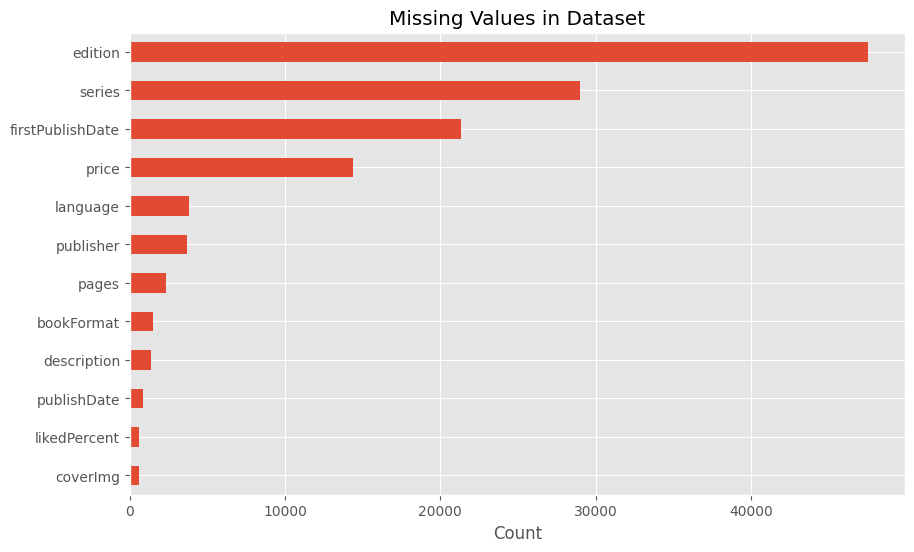

In [ ]:
missing = books.isnull().sum()
missing = missing[missing > 0]
plt.figure(figsize=(10,6))
missing.sort_values().plot(kind='barh')
plt.title("Missing Values in Dataset")
plt.xlabel("Count")
plt.show()

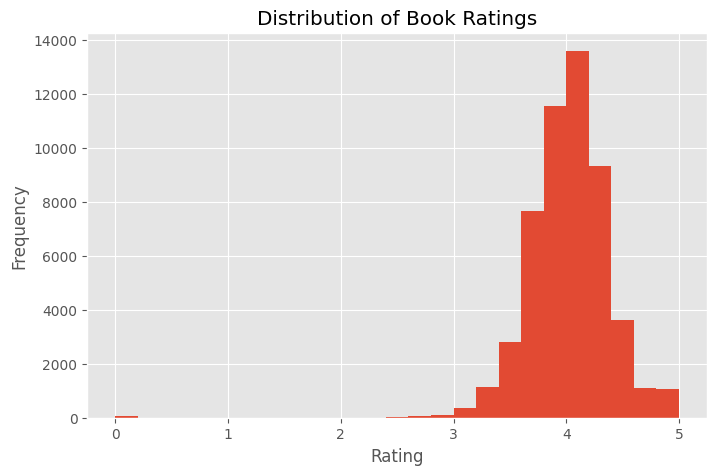

In [ ]:
plt.figure(figsize=(8,5))
books["rating"].hist(bins=25)
plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

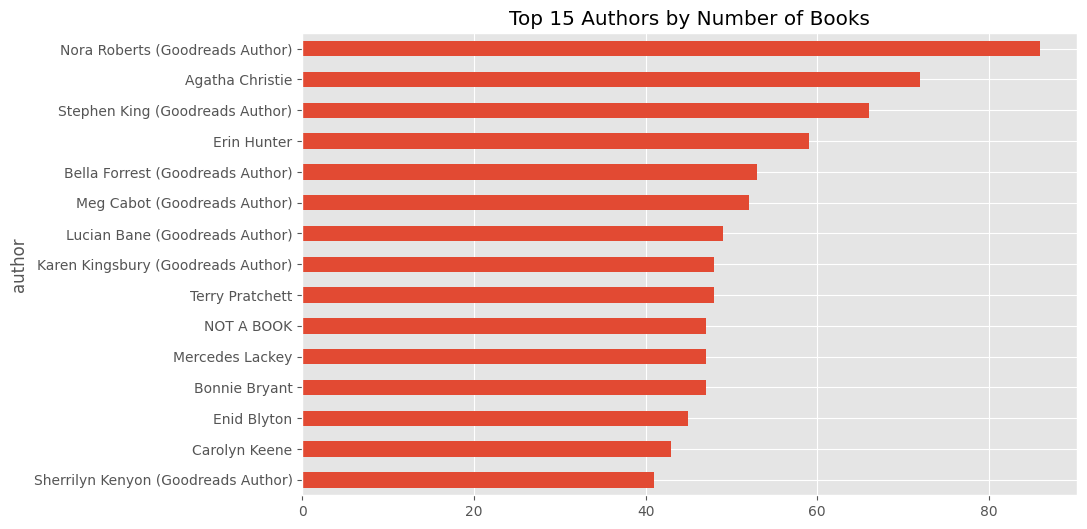

In [ ]:
top_authors = books["author"].value_counts().head(15)
plt.figure(figsize=(10,6))
top_authors.sort_values().plot(kind="barh")
plt.title("Top 15 Authors by Number of Books")
plt.show()